# This notebook calculates the expected event rate at DUNE across different zenith angle and energy bins.

## 1. Atmospheric neutrino flux

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as interp
from scipy.interpolate import RegularGridInterpolator

with open('hms-nu-20-01-000.d') as f:
    with open('hms-nu-20-01-n3650.d') as l:
        lines_min = (line for line in f if 'average' not in line and 'Enu' not in line)
        lines_max = (line for line in l if 'average' not in line and 'Enu' not in line)
        all_flux_data_min = np.loadtxt(lines_min)
        all_flux_data_max = np.loadtxt(lines_max)  

        flux_data_numu = (all_flux_data_min[:, [0, 1]] + all_flux_data_max[:, [0, 1]]) / 2
        numu_uncertainty = np.abs(all_flux_data_min[:, [0, 1]] - all_flux_data_max[:, [0, 1]]) / 2

        flux_data_numubar = (all_flux_data_min[:, [0, 2]] + all_flux_data_max[:, [0, 2]]) / 2
        numubar_uncertainty = np.abs(all_flux_data_min[:, [0, 2]] - all_flux_data_max[:, [0, 2]]) / 2

        flux_data_nue = (all_flux_data_min[:, [0, 3]] + all_flux_data_max[:, [0, 3]]) / 2
        nue_uncertainty = np.abs(all_flux_data_min[:, [0, 3]] - all_flux_data_max[:, [0, 3]]) / 2

        flux_data_nuebar = (all_flux_data_min[:, [0, 4]] + all_flux_data_max[:, [0, 4]]) / 2
        nuebar_uncertainty = np.abs(all_flux_data_min[:, [0, 4]] - all_flux_data_max[:, [0, 4]]) / 2

In [2]:
n_energy = 101
energies = all_flux_data_min[:n_energy, 0]
num_cos = len(all_flux_data_min) // n_energy
cos_bins_centers = np.linspace(-0.95, 0.95, num_cos)


def make_interpolator(data):
    """Create a 2D flux interpolator from [energy, value] blocks."""
    values = data[:, 1].reshape(num_cos, n_energy)
    return RegularGridInterpolator(
        (cos_bins_centers, energies),
        values,
        #method="cubic",
        method = "linear",
        bounds_error=False,
        fill_value=0,
    )


flux_data = {
    "numu": flux_data_numu,
    "numubar": flux_data_numubar,
    "nue": flux_data_nue,
    "nuebar": flux_data_nuebar,
}

uncertainty_data = {
    "numu": numu_uncertainty,
    "numubar": numubar_uncertainty,
    "nue": nue_uncertainty,
    "nuebar": nuebar_uncertainty,
}

flux_interpolators = {
    flavor: make_interpolator(data)
    for flavor, data in flux_data.items()
}

uncertainty_interpolators = {
    flavor: make_interpolator(data)
    for flavor, data in uncertainty_data.items()
}


def get_flux(cos_theta, energy, flavor="numu", uncertainty=False):
    """Return interpolated flux or its uncertainty for a flavor."""
    interpolators = uncertainty_interpolators if uncertainty else flux_interpolators
    points = np.column_stack([np.atleast_1d(cos_theta), np.atleast_1d(energy)])
    return interpolators[flavor](points)


# Example: central value and uncertainty for nu_mu.
test_cos = -0.12
test_energy = 1.5
print(f"nu_mu flux: {get_flux(test_cos, test_energy)[0]:.2e}")
print(f"nu_mu uncertainty: {get_flux(test_cos, test_energy, uncertainty=True)[0]:.2e}")
print(f"nu_mu-bar flux: {get_flux(test_cos, test_energy, flavor='numubar')[0]:.2e}")

nu_mu flux: 7.10e+01
nu_mu uncertainty: 1.07e+00
nu_mu-bar flux: 6.82e+01


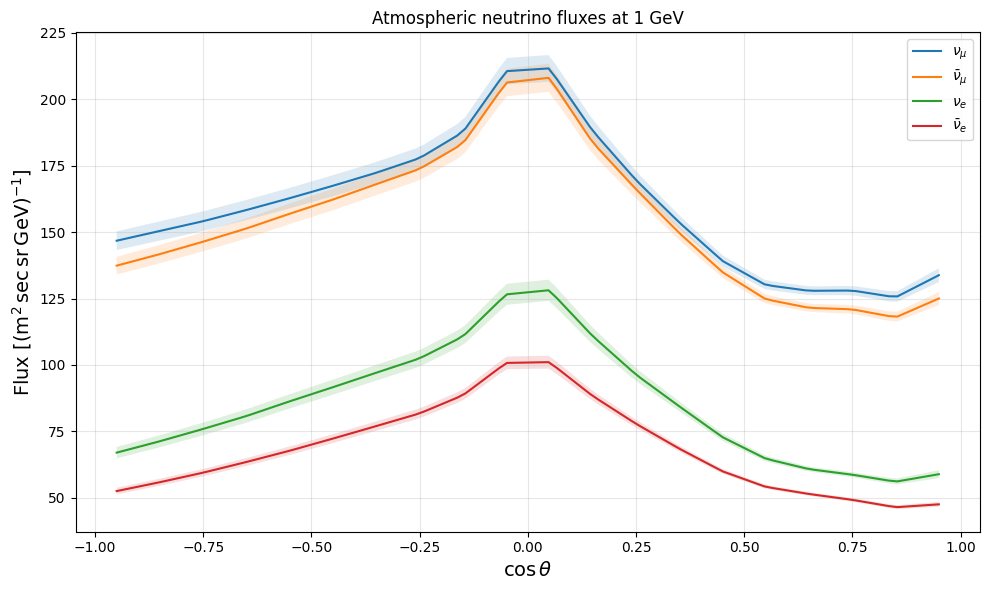

In [3]:
cos_grid = np.linspace(-0.95, 0.95, 100)
energy_to_plot = energies[20]
flavors = ["numu", "numubar", "nue", "nuebar"]
flavor_labels = {
    "numu": r"$\nu_\mu$",
    "numubar": r"$\bar{\nu}_\mu$",
    "nue": r"$\nu_e$",
    "nuebar": r"$\bar{\nu}_e$",
}

plt.figure(figsize=(10, 6))
for flavor in flavors:
    flux_values = np.array([
        get_flux(cos, energy_to_plot, flavor=flavor)[0]
        for cos in cos_grid
    ])
    uncertainty_values = np.array([
        get_flux(cos, energy_to_plot, flavor=flavor, uncertainty=True)[0]
        for cos in cos_grid
    ])

    plt.plot(cos_grid, flux_values, label=flavor_labels[flavor])
    plt.fill_between(
        cos_grid,
        flux_values - uncertainty_values,
        flux_values + uncertainty_values,
        alpha=0.15,
    )

plt.xlabel(r"$\cos\theta$", fontsize=14)
plt.ylabel(r"Flux $[(\mathrm{m^2\,sec\,sr\,GeV})^{-1}]$", fontsize=14)
plt.title(f"Atmospheric neutrino fluxes at {energy_to_plot:.2g} GeV")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("flux_zenith_solar_max.pdf", dpi=300)
plt.show()

Notice a couple things from this plot:
- Flux peaks at horizon (long decay path, not production)
- More up-going than down-going (geomagnetic field effect, more pronouced for low-energy flux)
- numu : nue $\approx$ 2:1 (pion decay chain)
- nu > nubar (more pi+ than pi-)

## 2. Xsec from GENIE

In [9]:
import uproot

energy_bins = np.linspace(0.5, 8.0, 62)
energy_bins_centers = (energy_bins[:-1] + energy_bins[1:]) / 2
energy_bins_edges = energy_bins
# Load the ROOT cross-section graph.
file = uproot.open("/Users/taozhou/Downloads/genie_xsec/v3_06_00/NULL/AR2320i00000-k250-e1000/data/xsec_graphs.root")
graph = file["nu_mu_Ar40"]["tot_cc;1"]
x_values = np.asarray(graph.member("fX"))
y_values = np.asarray(graph.member("fY"))

inter_xy = interp.interp1d(
    x_values,
    y_values,
    bounds_error=False,
    fill_value=0,
)
xsec = inter_xy(energy_bins_centers)

# Convert cross section from 10^-38 cm^2 to m^2 and scale by argon count.
conv = 1e-38 * 1e-4
noar = 20 * 1e3 * 1e6 * 6.022e23 / 39.948
scaled_xsec = conv * noar * xsec
scaled_xsec_uncertainty = None

np.savetxt("xsec.txt", xsec)

## 3. Angular resolution

In [ ]:
x_ang, y_ang = np.loadtxt("angular_resolution.txt", delimiter=",", skiprows=1, unpack=True)
inter_xy_ang = interp.interp1d(
    x_ang,
    y_ang,
    kind="linear",
    bounds_error=False,
    # Data only covers up to x_ang[-1] = 8.9116 GeV. Above that, hold the
    # angular resolution at its last measured value instead of dropping to
    # 0 (which previously made sigma=0 and broke the cos-theta smearing
    # for any E_grid point above ~8.9 GeV).
    fill_value=(y_ang[0], y_ang[-1]),
)
angular_res = inter_xy_ang(energy_bins_centers)

## 4. Oscillation probability

In [11]:
r = 6371 # earth radius in km
d = 20 # average altitude of neutrino production in the atmosphere in km
s = 1.5 # depth of DUNE FD in km

def zenith_to_baseline(x):
    """
    Convert zenith angle (cosine) to baseline length in km.
    """
    sqrt = np.sqrt(4*x**2*(s-r)**2-4*(s**2-2*r*s-d**2-2*r*d))
    L = 1/2 * (-2*x*(r-s) + sqrt)
    return L

def approx(x):
    L = -2*r*x
    return L

In [12]:
from oscillation_tools import (km, prob_full, calc_bin_centers, prob_2f, OscillationParameters, MeV, ThreeFlavorOscillation)
osc_model_vac = ThreeFlavorOscillation(rho=0, channel="mu_mu")
osc_model = ThreeFlavorOscillation(channel="mu_mu")

## 5. Event rate

Energy bin width: 0.123 GeV


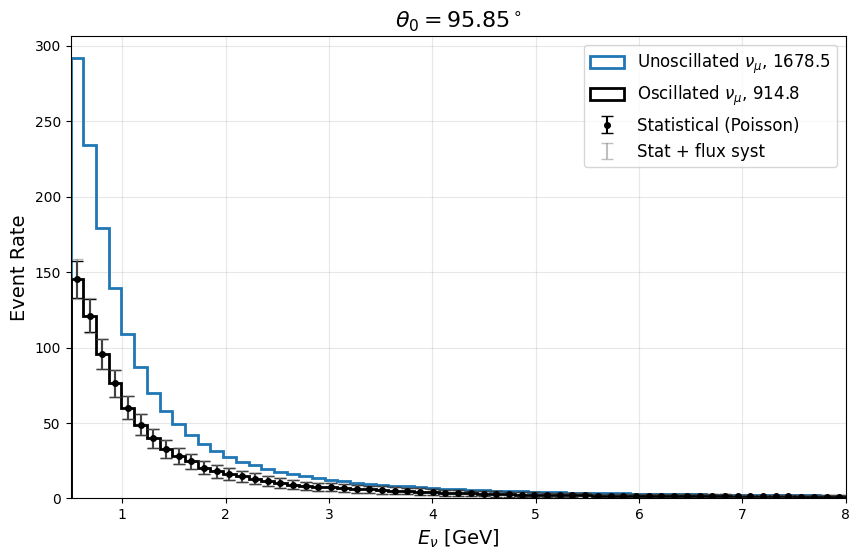

Total events (oscillated):   914.80
Total events (unoscillated): 1678.46
Total stat uncertainty:      179.40
Total flux syst uncertainty: 19.71
Total combined uncertainty:  182.10


In [13]:
plot_ratio = False
theta_0 = 95.85  # zenith angle in degrees for the DUNE FD
xsec = inter_xy(energy_bins_centers)
# 10^-38 cm^2 to m^2
conv = 1e-38 * 1e-4  # cm^2 to m^2
# number of argons for 20 kt FD
noar = 20 * 1e3 * 1e6 * 6.022e23 / 39.948
scaled_xsec = conv * noar * xsec

from scipy.integrate import simpson

# Calculate event rate for each energy bin
event_rate = np.zeros(len(energy_bins_centers))
event_rate_unosc = np.zeros(len(energy_bins_centers))
event_rate_uncertainty = np.zeros(len(energy_bins_centers))

time_factor = 3 * 365.25 * 24 * 3600  # 3 years in seconds
energy_bin_width = energy_bins[1] - energy_bins[0]

event_rate_stat = np.zeros(len(energy_bins_centers))
event_rate_syst = np.zeros(len(energy_bins_centers))

for i, E in enumerate(energy_bins_centers):

    def cos_lim(E):
        return (np.cos(np.radians(theta_0 + inter_xy_ang(E))),
                np.cos(np.radians(theta_0 - inter_xy_ang(E))))

    cos_limit = cos_lim(E)
    cos_grid = np.linspace(cos_limit[0], cos_limit[1], 100)

    # Flux and its uncertainty
    flux_values      = np.array([get_flux(cos, E)[0] for cos in cos_grid])
    flux_uncertainty = np.array([get_flux(cos, E, uncertainty=True)[0] for cos in cos_grid])

    # Oscillation probability (central value only)
    osc_prob = np.array([osc_model(L_km=zenith_to_baseline(cos), E_GeV=E) for cos in cos_grid])

    # Integrands
    common = scaled_xsec[i] * 2 * np.pi * time_factor * energy_bin_width

    integrand_osc   = flux_values * osc_prob * common
    integrand_unosc = flux_values * common

    integrand_osc_flux_upper = (flux_values + flux_uncertainty) * osc_prob * common
    integrand_osc_flux_lower = (flux_values - flux_uncertainty) * osc_prob * common

    # Integrate
    event_rate[i]       = simpson(integrand_osc,   x=cos_grid)
    event_rate_unosc[i] = simpson(integrand_unosc, x=cos_grid)

    rate_flux_upper = simpson(integrand_osc_flux_upper, x=cos_grid)
    rate_flux_lower = simpson(integrand_osc_flux_lower, x=cos_grid)

    # Systematics: flux only
    sigma_flux = 0.5 * (abs(rate_flux_upper - event_rate[i]) +
                        abs(event_rate[i]   - rate_flux_lower))

    # Statistical: Poisson
    sigma_stat = np.sqrt(max(event_rate[i], 0.0))

    event_rate_stat[i] = sigma_stat
    event_rate_syst[i] = sigma_flux
    event_rate_uncertainty[i] = np.sqrt(sigma_stat**2 + sigma_flux**2)

print(f"Energy bin width: {energy_bin_width:.3f} GeV")

# Plotting
plt.rcParams["text.usetex"] = False
plt.figure(figsize=(10, 6))

plt.hist(energy_bins_centers, weights=event_rate_unosc, bins=energy_bins_edges,
         histtype="step", label=rf'Unoscillated $\nu_\mu$, ${np.sum(event_rate_unosc):.1f}$',
         linewidth=2)
plt.hist(energy_bins_centers, weights=event_rate, bins=energy_bins_edges,
         histtype="step", label=rf'Oscillated $\nu_\mu$, ${np.sum(event_rate):.1f}$',
         linewidth=2, color='black')

# Statistical error bars
plt.errorbar(energy_bins_centers, event_rate, yerr=event_rate_stat,
             fmt='o', color='black', markersize=4, capsize=4,
             label='Statistical (Poisson)')

# Total uncertainty band
plt.errorbar(energy_bins_centers, event_rate, yerr=event_rate_uncertainty,
             fmt='none', ecolor='gray', alpha=0.5, capsize=4,
             label='Stat + flux syst')

plt.xlabel(r"$E_{\nu}$ [GeV]", fontsize=14)
plt.ylabel("Event Rate", fontsize=14)
plt.xlim(0.5, 8)
plt.legend(fontsize=12)
plt.title(rf"$\theta_0 = {theta_0}^\circ$", fontsize=16)
plt.grid(True, alpha=0.3)

plt.savefig(f"event_rate_with_uncertainties_{theta_0}.pdf", dpi=300)
plt.show()

print(f"Total events (oscillated):   {np.sum(event_rate):.2f}")
print(f"Total events (unoscillated): {np.sum(event_rate_unosc):.2f}")
print(f"Total stat uncertainty:      {np.sum(event_rate_stat):.2f}")
print(f"Total flux syst uncertainty: {np.sum(event_rate_syst):.2f}")
print(f"Total combined uncertainty:  {np.sum(event_rate_uncertainty):.2f}")

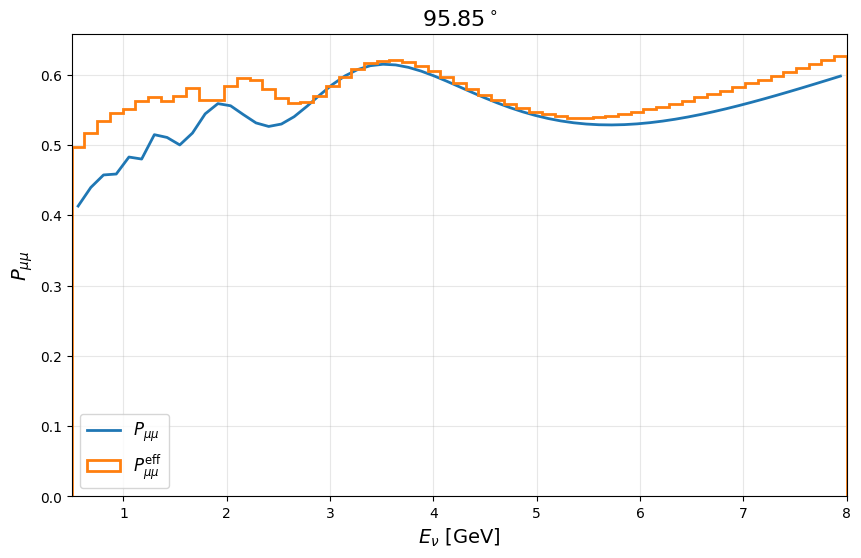

In [14]:
p_mm = np.zeros(len(energy_bins_centers))
for i in range(len(cos_grid)):
    p_mm += [osc_model(L_km=zenith_to_baseline(cos_grid[i]), E_GeV=E) for E in energy_bins_centers]
plt.figure(figsize=(10, 6))
plt.plot(energy_bins_centers, p_mm/100, label=r'$P_{\mu\mu}$', linewidth=2)
plt.hist(energy_bins_centers, weights=event_rate/event_rate_unosc, bins=energy_bins_edges, histtype="step", label=r"$P_{\mu\mu}^{\mathrm{eff}}$", linewidth=2)
plt.xlabel(r"$E_{\nu}$ [GeV]", fontsize=14)
plt.ylabel(r"$P_{\mu\mu}$", fontsize=14)
plt.xlim(0.5, 8)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.title(fr'$95.85^\circ$', fontsize=16)
plt.savefig(f"p_mumu_cos_{cos_limit[0]:.3f}_{cos_limit[1]:.3f}.pdf", dpi=300)

## Oscillogram with a constant matter density (2.8g/cm^3)

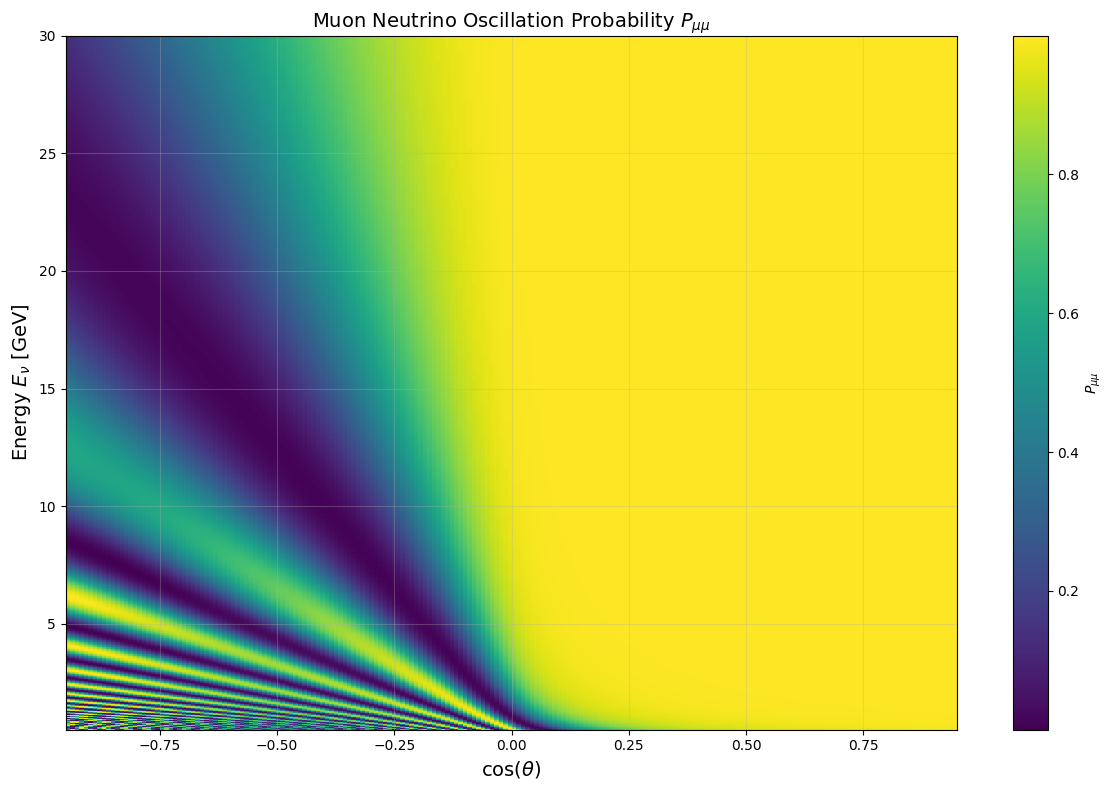

Probability range: 0.0000 to 1.0000


In [15]:

# Create heatmap: zenith angle vs energy with probability as color
zenith_angles = np.linspace(-0.95, 0.95, 200)
# energies_for_heatmap = energy_bins_centers
energies_for_heatmap = np.linspace(0.5, 30, 1000)
# Create 2D grid of probabilities
prob_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
for i, E in enumerate(energies_for_heatmap):
    for j, cos_z in enumerate(zenith_angles):
        prob_grid[i, j] = osc_model(L_km=zenith_to_baseline(cos_z), E_GeV=E)

# Plot heatmap
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower', 
                extent=[zenith_angles[0], zenith_angles[-1], 
                        energies_for_heatmap[0], energies_for_heatmap[-1]],
                cmap='viridis', interpolation='nearest')

plt.xlabel(r'$\cos(\theta)$', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
#plt.yscale('log')
plt.title(r'Muon Neutrino Oscillation Probability $P_{\mu\mu}$', fontsize=14)

cbar = plt.colorbar(im, label=r'$P_{\mu\mu}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('p_mumu_oscillogram.pdf', dpi=300)
plt.show()

print(f"Probability range: {prob_grid.min():.4f} to {prob_grid.max():.4f}")


## Oscillogram with 3 layer profile

In [ ]:
# from oscillation_tools import VaryingDensityOscillation

# osc_model_profile = VaryingDensityOscillation(channel="mu_mu")

# # Create heatmap: zenith angle vs energy with probability as color
# zenith_angles = np.linspace(-0.95, 0.95, 100)
# # energies_for_heatmap = energy_bins_centers
# energies_for_heatmap = np.linspace(0.5, 30, 100)
# # Create 2D grid of probabilities
# prob_grid = np.zeros((len(energies_for_heatmap), len(zenith_angles)))
# for i, E in enumerate(energies_for_heatmap):
#     for j, cos_z in enumerate(zenith_angles):
#         prob_grid[i, j] = osc_model_profile(L_km=zenith_to_baseline(cos_z), E_GeV=E)

# # Plot heatmap
# plt.figure(figsize=(12, 8))
# im = plt.imshow(prob_grid, aspect='auto', origin='lower', 
#                 extent=[zenith_angles[0], zenith_angles[-1], 
#                         energies_for_heatmap[0], energies_for_heatmap[-1]],
#                 cmap='viridis', interpolation='nearest')

# plt.xlabel(r'$\cos(\theta)$', fontsize=14)
# plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
# #plt.yscale('log')
# plt.title(r'Muon Neutrino Oscillation Probability $P_{\mu\mu}$', fontsize=14)

# cbar = plt.colorbar(im, label=r'$P_{\mu\mu}$')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig('p_mumu_oscillogram_profile.pdf', dpi=300)
# plt.show()

# print(f"Probability range: {prob_grid.min():.4f} to {prob_grid.max():.4f}")



KeyboardInterrupt: 

## Event rate oscillogram

In [ ]:
cos_grid = np.linspace(-0.95, 0.95, 100)   # x axis
E_grid           = np.linspace(0.5, 10, 100)
energy_bin_width = E_grid[1] - E_grid[0]
d_cos            = cos_grid[1] - cos_grid[0]

xsec_grid        = conv * noar * inter_xy(E_grid)
angular_res_grid = inter_xy_ang(E_grid)

Prob      = np.zeros((len(E_grid), len(cos_grid)))
R      = np.zeros((len(E_grid), len(cos_grid)))
R_stat = np.zeros_like(R)
R_syst = np.zeros_like(R)
R_tot  = np.zeros_like(R)

for i, E in enumerate(E_grid):
    for j, cos in enumerate(cos_grid):
        flux  = get_flux(cos, E)[0]
        dflux = get_flux(cos, E, uncertainty=True)[0]
        L     = zenith_to_baseline(cos)
        P     = osc_model(L_km=L, E_GeV=E)

        cell = flux * P * xsec_grid[i] * 2*np.pi * time_factor * energy_bin_width * d_cos
        R[i, j] = cell
        Prob[i, j] = P
        # Poisson
        R_stat[i, j] = np.sqrt(max(cell, 0))

        # Flux systematic
        s_flux = (dflux / flux) * cell if flux > 0 else 0

        # Angular resolution systematic
        delta     = 1e-5
        dL_dcos   = (zenith_to_baseline(cos + delta) - zenith_to_baseline(cos - delta)) / (2 * delta)
        sin_theta = np.sqrt(1 - cos**2)
        dL        = abs(dL_dcos) * sin_theta * np.radians(angular_res_grid[i])

        cell_u = flux * osc_model(L_km=L + dL, E_GeV=E) * xsec_grid[i] * 2*np.pi * time_factor * energy_bin_width * d_cos
        cell_l = flux * osc_model(L_km=L - dL, E_GeV=E) * xsec_grid[i] * 2*np.pi * time_factor * energy_bin_width * d_cos
        s_ang  = 0.5 * abs(cell_u - cell_l)

        R_syst[i, j] = np.hypot(s_flux, s_ang)
        R_tot[i, j]  = np.hypot(R_stat[i, j], R_syst[i, j])

# Smeared event rate calculation: convolve the observable rate along
# cos(theta) with the detector's angular response.
#
# Two fixes vs. the previous version:
# 1. We smear the full rate R, not the oscillation probability P alone
#    (then re-multiplying by the un-smeared flux). flux(cos) varies
#    sharply with cos(theta) -- it peaks at the horizon -- so
#    smear(flux * P) != flux * smear(P); smearing R is what a detector
#    with finite angular resolution actually measures.
# 2. sigma_pixels is floored above zero. angular_res_grid comes from
#    interpolating angular_resolution.txt, which only covers up to
#    ~8.91 GeV; inter_xy_ang's fill_value=0 makes angular_res_grid
#    exactly 0 for E_grid points above that (about 12 of the 100 rows,
#    since E_grid runs up to 10 GeV). sigma=0 previously fed straight
#    into gaussian_filter1d, which divides by sigma**2 internally --
#    that's the "divide by zero" / "invalid value encountered in
#    multiply" RuntimeWarnings this cell was raising, and it left those
#    rows (E > ~8.9 GeV) as NaN in R_smeared.
from scipy.ndimage import gaussian_filter1d

R_smeared = np.zeros_like(R)
for i, E in enumerate(E_grid):
    ang_res_rad    = np.radians(angular_res_grid[i])
    sin_theta_mean = np.sqrt(1 - np.mean(cos_grid**2))
    sigma_cos      = sin_theta_mean * ang_res_rad
    sigma_pixels   = max(sigma_cos / abs(d_cos), 1e-3)

    R_smeared[i, :] = gaussian_filter1d(R[i, :], sigma=sigma_pixels, mode='nearest')

R_smeared = np.clip(R_smeared, 0, None)

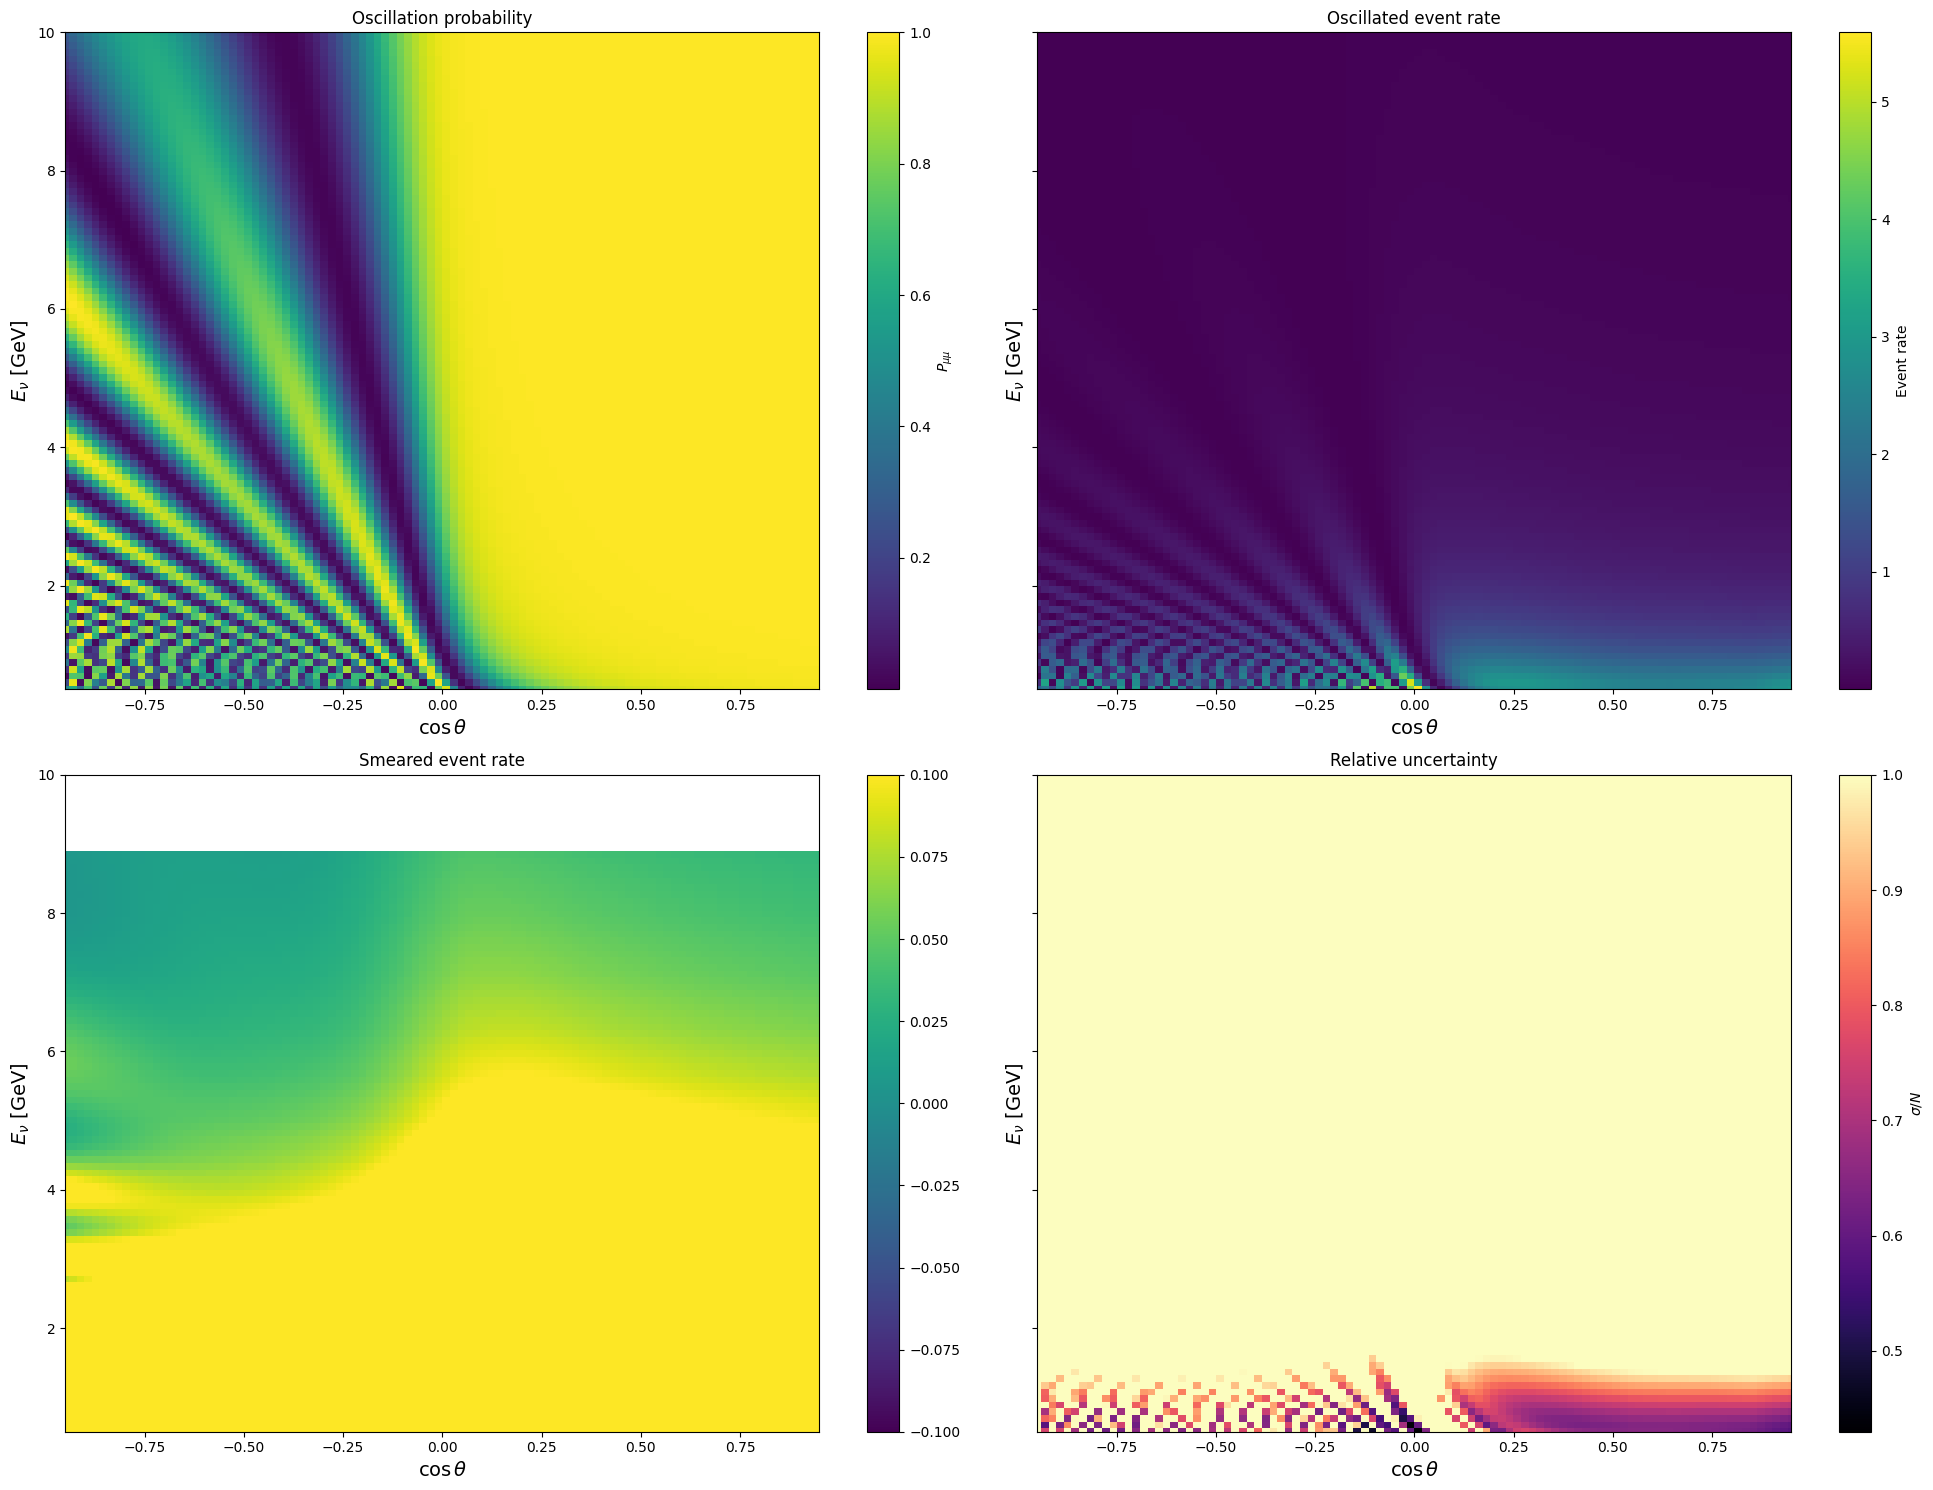

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15), sharey=True)

# Panel 1: oscillogram
pc2 = axes[0,0].pcolormesh(cos_grid, E_grid, Prob, shading='auto',
                          cmap='viridis', vmax=1.0)
fig.colorbar(pc2, ax=axes[0,0], label=r'$P_{\mu\mu}$')
axes[0,0].set_title('Oscillation probability')

# Panel 2: event rate
pc0 = axes[0,1].pcolormesh(cos_grid, E_grid, R, shading='auto', cmap='viridis')
fig.colorbar(pc0, ax=axes[0,1], label='Event rate')
axes[0,1].set_title('Oscillated event rate')

# Panel 3: smeared event rate
pc3 = axes[1,0].pcolormesh(cos_grid, E_grid, R_smeared, shading='auto',
                          cmap='viridis', vmax=R_smeared.max())
fig.colorbar(pc3, ax=axes[1,0])
axes[1,0].set_title('Smeared event rate')

# Panel 4: relative total uncertainty
rel_unc = np.divide(R_tot, R, out=np.zeros_like(R), where=R>0)
pc1 = axes[1,1].pcolormesh(cos_grid, E_grid, rel_unc, shading='auto',
                          cmap='magma', vmax=1.0)
fig.colorbar(pc1, ax=axes[1,1], label=r'$\sigma / N$')
axes[1,1].set_title('Relative uncertainty')

for ax in axes.flat:
    ax.set_xlabel(r'$\cos\theta$', fontsize=14)
    ax.set_ylabel(r'$E_\nu$ [GeV]', fontsize=14)
    ax.set_xlim(-0.95, 0.95)
    ax.set_ylim(0.5, 10)
plt.tight_layout()
plt.savefig('event_rate_uncertainty_oscillogram.pdf', dpi=300)
plt.show()